# =============================================
# PERTEMUAN 9: Algoritma Klasifikasi (Bagian 1)
## Prediksi Diagnosis
# =============================================
* Nama: Nida'an Khafiyya
* NIM: 250401020123
* Kelas: IF401

## Import Library

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

## Load & EDA Dataset

In [22]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target # 0=malignant, 1=benign

print('Shape:', X.shape)
print('Distribusi target:')
print(pd.Series(y).value_counts(normalize=True).round(3))

Shape: (569, 30)
Distribusi target:
1    0.627
0    0.373
Name: proportion, dtype: float64


Dataset Breast Cancer Wisconsin telah dimuat menggunakan fungsi load_breast_cancer() dan dikonversi ke dalam bentuk DataFrame. Hasil eksplorasi awal menunjukkan bahwa dataset memiliki 569 sampel dengan 30 fitur numerik yang merepresentasikan karakteristik sel tumor. Distribusi target memperlihatkan bahwa kelas benign (1) mendominasi sebesar 62,7%, sedangkan kelas malignant (0) sebesar 37,3%.

## Preprocessing

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Pada tahap preprocessing, dataset dibagi menjadi data latih dan data uji dengan rasio 80:20 menggunakan train_test_split(), serta parameter stratify=y untuk menjaga proporsi kelas malignant dan benign tetap seimbang pada kedua subset data.

Selanjutnya, fitur dinormalisasi menggunakan StandardScaler dengan menghitung parameter skala pada data latih (fit_transform) dan menerapkannya pada data uji (transform) guna menghindari data leakage. Proses standardisasi ini penting untuk algoritma seperti Logistic Regression karena meningkatkan stabilitas dan performa model, meskipun tidak menjadi keharusan bagi algoritma berbasis pohon keputusan seperti Decision Tree.

## Train Logistic Regression

In [24]:
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_s, y_train)
y_pred_log = log_model.predict(X_test_s)

print('Fitur yang Berpengaruh Terhadap Diagnosis pada Logistic Regression:')
coef_df = pd.DataFrame({'Fitur': X.columns,
    'Koefisien': log_model.coef_[0]
    }).sort_values('Koefisien', key=abs, ascending=False)
print(coef_df.head())

Fitur yang Berpengaruh Terhadap Diagnosis pada Logistic Regression:
                   Fitur  Koefisien
21         worst texture  -1.255088
10          radius error  -1.082965
27  worst concave points  -0.953686
23            worst area  -0.947756
20          worst radius  -0.947616


Model Logistic Regression dilatih menggunakan data yang telah melalui proses standardisasi sebelumnya. Setelah pelatihan, nilai koefisien model dianalisis untuk mengidentifikasi fitur yang paling berpengaruh terhadap prediksi diagnosis kanker payudara.

Hasil menunjukkan bahwa fitur seperti worst texture, radius error, worst concave points, worst area, dan worst radius memiliki nilai koefisien terbesar (dalam nilai absolut), sehingga memberikan kontribusi paling kuat dalam membedakan antara tumor malignant dan benign pada proses klasifikasi.

## Train Decision Tree

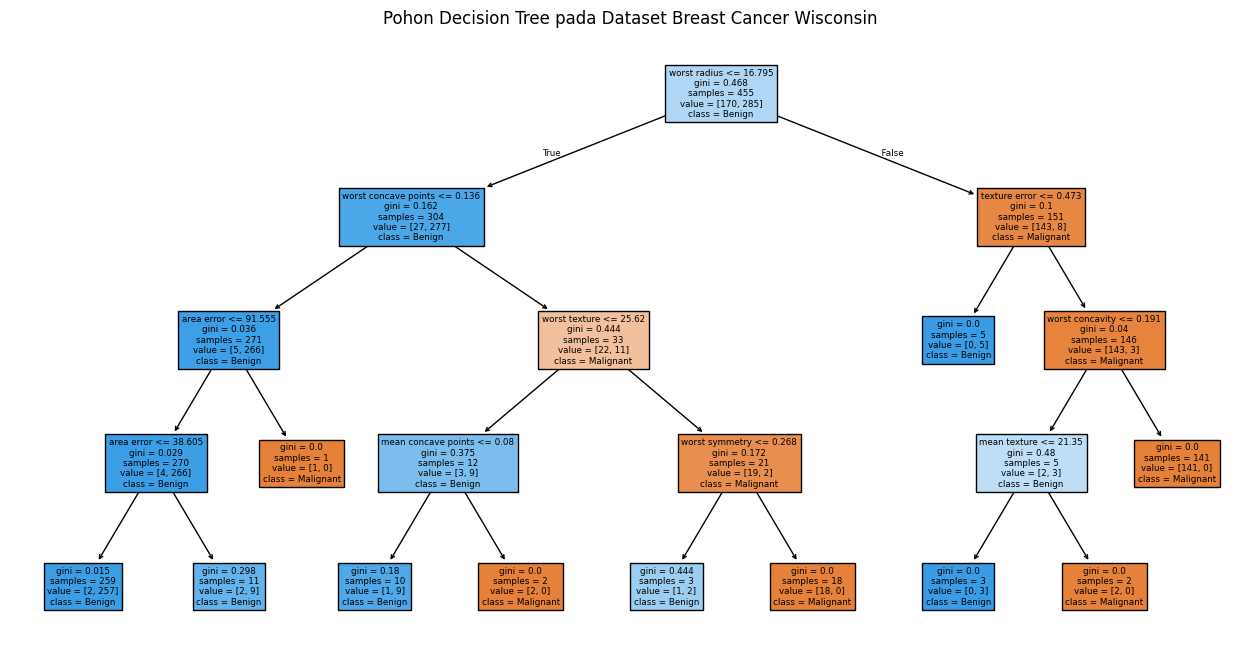

In [25]:
tree_model = DecisionTreeClassifier(max_depth=4,
    random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

plt.figure(figsize=(16, 8))
plot_tree(tree_model, feature_names=X.columns,
    class_names=['Malignant','Benign'], filled=True)
plt.title('Pohon Decision Tree pada Dataset Breast Cancer Wisconsin')
plt.show()

Model Decision Tree dilatih menggunakan data asli tanpa proses standardisasi karena algoritma berbasis pohon tidak dipengaruhi oleh perbedaan skala fitur.

Dari hasil visualisasi pohon keputusan dengan plot_tree() menunjukkan bahwa fitur seperti worst radius, worst concave points, texture error, dan area error menjadi kriteria utama dalam proses pemisahan data untuk menentukan diagnosis tumor. Struktur pohon dengan max_depth=4 menghasilkan aturan klasifikasi yang mudah diinterpretasikan, di mana setiap node menampilkan kondisi pemisahan, nilai gini impurity, jumlah sampel, distribusi kelas, serta prediksi akhir berupa Malignant atau Benign.

## Evaluate & Compare

In [26]:
from sklearn.metrics import (confusion_matrix,
    accuracy_score, precision_score,
    recall_score, f1_score)

print('====== Confusion Matrix ======')
for name, y_pred in [('Logistic Regression', y_pred_log),
                      ('Decision Tree', y_pred_tree)]:
    print(f"\n=== {name} ===")
    print(confusion_matrix(y_test, y_pred))
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision: {precision_score(y_test, y_pred):.3f}")
    print(f"Recall : {recall_score(y_test, y_pred):.3f}")
    print(f"F1-Score : {f1_score(y_test, y_pred):.3f}")

====== Confusion Matrix ======

=== Logistic Regression ===
[[41  1]
 [ 1 71]]
Accuracy : 0.982
Precision: 0.986
Recall : 0.986
F1-Score : 0.986

=== Decision Tree ===
[[39  3]
 [ 4 68]]
Accuracy : 0.939
Precision: 0.958
Recall : 0.944
F1-Score : 0.951


Kinerja model dievaluasi menggunakan Confusion Matrix, Accuracy, Precision, Recall, dan F1-Score untuk mengukur kemampuan klasifikasi pada data uji. Hasil evaluasi menunjukkan bahwa Logistic Regression memperoleh performa terbaik dengan Accuracy 98,2%, Precision 98,6%, Recall 98,6%, dan F1-Score 98,6%, sedangkan Decision Tree mencapai Accuracy 93,9%, Precision 95,8%, Recall 94,4%, dan F1-Score 95,1%.

Perbandingan ini mengindikasikan bahwa Logistic Regression lebih unggul dalam mendeteksi kasus kanker secara tepat dan menghasilkan jumlah kesalahan klasifikasi yang lebih sedikit dibandingkan Decision Tree.

## Pembahasan

**Perbandingan Recall Kedua Model**
Berdasarkan hasil evaluasi, Logistic Regression memiliki Recall yang lebih tinggi (0,986) dibandingkan Decision Tree (0,944). Artinya, Logistic Regression mampu mengidentifikasi lebih banyak kasus positif yang sebenarnya dibandingkan Decision Tree. Dengan kata lain, jumlah kasus kanker yang berpotensi terlewat (False Negative) pada Logistic Regression lebih sedikit.


**Mengapa Recall Sangat Penting pada Diagnosis Kanker?**
Dalam kasus diagnosis kanker, Recall merupakan metrik yang paling kritis karena tujuan utama sistem adalah mendeteksi sebanyak mungkin pasien yang benar-benar menderita kanker. Kesalahan berupa False Negative (pasien kanker diprediksi sehat) dapat menyebabkan keterlambatan penanganan medis yang berisiko memperburuk kondisi pasien bahkan mengancam keselamatan jiwa.

Sebaliknya, False Positive memang dapat menimbulkan pemeriksaan lanjutan yang tidak diperlukan, namun dampaknya umumnya tidak separah melewatkan pasien yang sebenarnya mengidap kanker. Oleh karena itu, model dengan Recall yang lebih tinggi biasanya lebih diutamakan dalam aplikasi medis.

**Apakah Ada Perbedaan Signifikan Antara Kedua Model?**
Ya, terdapat perbedaan performa yang cukup jelas antara kedua model. Logistic Regression unggul pada seluruh metrik evaluasi, termasuk Accuracy (98,2% vs 93,9%), Recall (98,6% vs 94,4%), dan F1-Score (98,6% vs 95,1%). Meskipun kedua model menunjukkan performa yang baik, Logistic Regression menghasilkan prediksi yang lebih konsisten dan lebih sedikit kesalahan klasifikasi.

Oleh karena itu, untuk kasus deteksi kanker payudara pada dataset ini, Logistic Regression merupakan pilihan yang lebih baik karena mampu memberikan tingkat deteksi kasus yang lebih tinggi dan risiko False Negative yang lebih rendah.